In [1]:
#%pip install --upgrade shap

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as utils_data
from torch.autograd import Variable

import shap

from sklearn.preprocessing import MinMaxScaler 
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

import pickle
import json
import os
import warnings
import datetime

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"{torch.cuda.device_count()} GPU(s) available and will be used.\nGPU name(s): {[torch.cuda.get_device_name(n) for n in range(torch.cuda.device_count())]}")
else:
    device = torch.device("cpu")
    print("GPU not available, using CPU.")

1 GPU(s) available and will be used.
GPU name(s): ['Tesla V100-PCIE-16GB']


In [4]:
RANDOM_STATE = 42

In [5]:
class tanh_MLP(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, output_size):
        super(tanh_MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.fc3 = nn.Linear(hidden_size2, output_size)
        
    def forward(self, x):
        x = F.tanh(self.fc1(x))
        x = F.tanh(self.fc2(x))
        out = self.fc3(x)
        return out

In [6]:
# Instantiate a dataframe on first dataset to get columns
nfl_df = pd.read_csv('../dataset_generators/datasets/0_train_normalized.csv')
# Get normalized columns
y = ['fantasy_points']
X = [col for col in nfl_df.columns if col not in ('player_id'
                                                        , 'player_name'
                                                        , 'player_display_name'
                                                        , 'position','position_group'
                                                        , 'headshot_url'
                                                        , 'season'
                                                        , 'week'
                                                        , 'season_type'
                                                        , 'team'
                                                        , 'opponent_team'
                                                        , 'fantasy_points'
                                                        , 'Unnamed: 0')]
del nfl_df

In [49]:
# The best model is the one below
model = '_100-100_tanh_100_0.0001_norm.pickle'


train_dataset_name = '_train_normalized.csv'
test_dataset_name = '_test_normalized.csv'

all_shap_values = []
all_inputs = []

feature_importances_dict = {}
# Iterate over all 5 versions of the model that were trained on the KFold cross validation sets
for n in range(5):
    # Load the model    
    model_name = f'../model_generators/mlp/models/{n}{model}'
    with open(model_name, 'rb') as f:
        #print(model)
        mlp = pickle.load(f)
        mlp.eval()
    # Get the scaler
    train_data_df = pd.read_csv(f'../dataset_generators/datasets/{n}{train_dataset_name}')
    test_data_df = pd.read_csv(f'../dataset_generators/datasets/{n}{test_dataset_name}')
    new_train_df_x = train_data_df[X]
    new_test_df_x = test_data_df[X]
    new_test_df_y = test_data_df[y]
    with torch.no_grad():
        y_pred = mlp(torch.tensor(new_test_df_x.values, dtype=torch.float32)).squeeze()
        baseline_score = mean_absolute_error(new_test_df_y, y_pred.cpu().numpy())
    
    feature_importances = {}
    num_features = len(X)
    
    for n2 in range(num_features):
        X_permuted = new_test_df_x.copy()
        col_name = X[n2]
        shuffled_col = X_permuted[col_name].values.copy()
        np.random.shuffle(shuffled_col)
        X_permuted[col_name] = shuffled_col
        with torch.no_grad():
            permuted_preds = mlp(torch.tensor(X_permuted.values, dtype=torch.float32)).squeeze()
            permuted_score = mean_absolute_error(new_test_df_y, permuted_preds.cpu().numpy())
    
        feature_importances[f'Feature_{n2}'] = permuted_score - baseline_score
    
    feature_importances_dict[n] = feature_importances
    

In [50]:
fin_feature_importance = []
for n in range(len(X)):
    avg_feature_importance = feature_importances_dict[0][f'Feature_{n}'] + feature_importances_dict[1][f'Feature_{n}'] + feature_importances_dict[2][f'Feature_{n}'] + feature_importances_dict[3][f'Feature_{n}'] + feature_importances_dict[4][f'Feature_{n}']
    avg_feature_importance = avg_feature_importance/5
    
    fin_feature_importance.append((X[n], avg_feature_importance))

In [75]:
fi_df = pd.DataFrame(fin_feature_importance, columns=['feature','importance'])

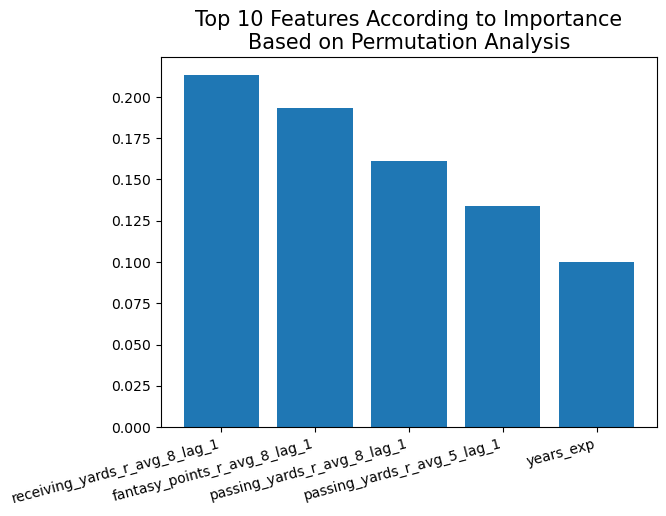

In [86]:
fi_df = fi_df.sort_values('importance',ascending=False)
fi_df_top10 = fi_df.iloc[:5]
plt.bar(fi_df_top10['feature'], fi_df_top10['importance'])
plt.xticks(rotation=15, ha='right')
plt.title('Top 10 Features According to Importance\nBased on Permutation Analysis', fontsize=15)
plt.show()

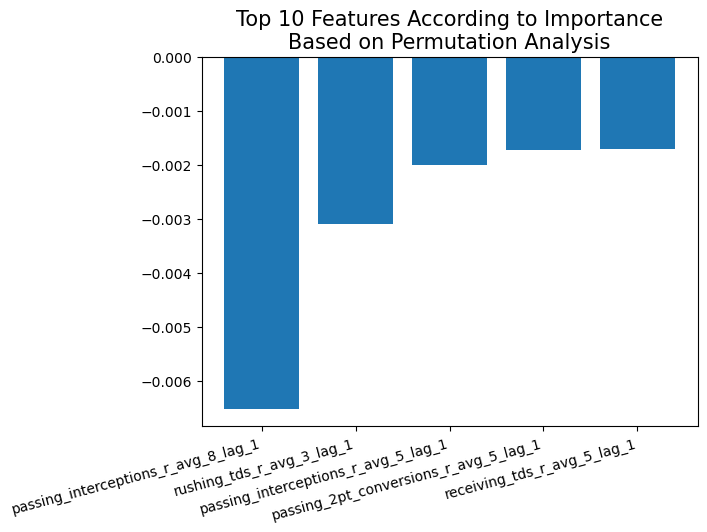

In [85]:
fi_df = fi_df.sort_values('importance',ascending=True)
fi_df_bot10 = fi_df.iloc[:5]
plt.bar(fi_df_bot10['feature'], fi_df_bot10['importance'])
plt.xticks(rotation=15, ha='right')
plt.title('Top 10 Features According to Importance\nBased on Permutation Analysis', fontsize=15)
plt.show()